In [ ]:
!pip install scikit-learn polars matplotlib

In [ ]:
import math
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state"
)

In [4]:
train_in = pd.read_csv('./data/train_in.csv', header=None)
train_out = pd.read_csv('./data/train_out.csv', header=None)
test_in = pd.read_csv('./data/test_in.csv', header=None)
test_out = pd.read_csv('./data/test_out.csv', header=None)

In [10]:
train_out.head()

,0
0,6
1,5
2,4
3,7
4,3


In [11]:
X = train_in.values
y = train_out.values
X

array([[-1.   , -1.   , -1.   , ..., -1.   , -1.   , -1.   ],
       [-1.   , -1.   , -1.   , ..., -0.671, -0.828, -1.   ],
       [-1.   , -1.   , -1.   , ..., -1.   , -1.   , -1.   ],
       ...,
       [-1.   , -1.   , -1.   , ..., -1.   , -1.   , -1.   ],
       [-1.   , -1.   , -1.   , ..., -1.   , -1.   , -1.   ],
       [-1.   , -1.   , -1.   , ..., -1.   , -1.   , -1.   ]],
      shape=(1707, 256))

In [7]:
n_layers = 10   # each network will have 10 hidden layers, and each hidden layer 257 perceptrons 
n_perceptrons = 257
weight_matrix = []
bias_matrix = []

for i in range(n_layers):
    Weights = [np.zeros(n_features) for _ in range(n_perceptrons)]
    Bias = 0
    weight_matrix.append(Weights)
    bias_matrix.append(Bias)

class Perceptron():
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias
    
    def activation_function(self, x):
        return x if x > 0 else 0

    def compute_output(self, X):
        linear_output = np.matmul(X, self.weights) + self.bias
        return self.activation_function(linear_output)


class GradientDescentOptimizer():
    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate

    def update_weights(self, weights, gradients):
        return weights - self.learning_rate * gradients

    def update_bias(self, bias, gradient):
        return bias - self.learning_rate * gradient


class NeuralNetwork():
    def __init__(self, learning_rate=0.01, n_epochs=1000, n_layers=10, n_perceptrons=257, n_features=257, n_classes=10):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.n_layers = n_layers
        self.n_perceptrons = n_perceptrons
        self.n_features = n_features
        self.n_classes = n_classes
        self.optimizer = GradientDescentOptimizer(learning_rate=self.learning_rate)
        self.W0 = [np.random.rand(self.n_features) for _ in range(self.n_perceptrons)]
        self.W1 = [np.random.rand(self.n_perceptrons) for _ in range(self.n_perceptrons)]
        self.W2 = [np.random.rand(self.n_perceptrons) for _ in range(self.n_classes)]
        self.bias = []
        self.perceptrons = []
        self.loss_values = []
        for i in range(self.n_layers):
            weights = [np.random.rand(self.n_perceptrons) for _ in range(self.n_perceptrons)]
            bias = np.random.rand()
            self.W1.append(weights)
            self.bias.append(bias)

            # set up perceptrons for each layer
            for j in range(self.n_perceptrons):
                if i == 0:
                    perceptron = Perceptron(weights=self.W0[i][j], bias=bias)
                else:
                    perceptron = Perceptron(weights=self.W1[i][j], bias=bias)
                self.perceptrons.append(perceptron)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        #self.weights = np.zeros(n_features)
        #self.weights = np.random.rand(n_features)

        for _ in range(self.n_epochs):
            for idx, x_i in enumerate(X):
                inputs = x_i
                for layer in range(self.n_layers):
                    output_values = []
                    if layer < self.n_layers - 1:  # For all layers except the last one
                        for perceptron in self.perceptrons[layer*self.n_perceptrons:(layer+1)*self.n_perceptrons]:
                            output_value = perceptron.compute_output(inputs)
                            output_values.append(output_value)

                        inputs = np.array(output_values)
                    else:
                        for perceptron in self.perceptrons[layer*self.n_perceptrons:(layer+1)*self.n_perceptrons]:
                            output_value = self.sigmoid(np.dot(perceptron.weights, inputs) + perceptron.bias)
                            output_values.append(output_value)
                        
                        inputs = np.array(output_values)
                        y_predicted = np.argmax(output_values)  # For the last layer, we take the index of the maximum output as the predicted class
                   
                    

            

                #y_predicted = self._activation_function(linear_output)

                update = self.learning_rate * (y[idx] - y_predicted)
                loss_value = self._loss_function(y_predicted, y[idx])
                gradients = -2 * (y[idx] - y_predicted) * x_i
                self.weights = self.optimizer.update_weights(self.weights, gradients)
                self.bias = self.optimizer.update_bias(self.bias, update)
                self.loss_values.append(loss_value)




    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _loss_function(self, y_predicted, y_true):
        return np.mean((y_predicted - y_true) **2)

    def plot_loss_function(self):
        plt.plot(self.loss_values)
        plt.title("Loss Function over Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.show()




NameError: name 'n_features' is not defined

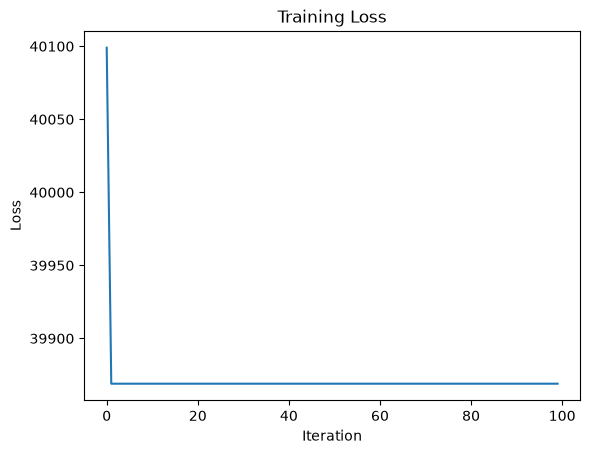

In [12]:
import matplotlib.pyplot as plt


class GradientDescentOptimizer:
    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate

    def update_weights(self, weights, gradients):
        return weights - self.learning_rate * gradients

    def update_bias(self, bias, gradient):
        return bias - self.learning_rate * gradient


class OneLayerPerceptronNeuralNetwork:
    def __init__(self, learning_rate=0.01, n_iter=100, n_perceptrons=10):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.n_perceptrons = n_perceptrons
        self.weights = None
        self.bias = None
        self.optimizer = GradientDescentOptimizer(learning_rate=self.learning_rate)
        self.loss_values = []

    def ReLU(self, values):
        return np.maximum(values, 0)

    def sigmoid(self, values):
        return 1 /(1 + np.exp(-values))

    def tanh(self, values):
        return np.tanh(values)

    def _activation_derivative(self, values):
        return (values > 0).astype(float)

    def compute_output(self, X):
        linear_output = self.weights.T @ X + self.bias
        return self.ReLU(linear_output)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        if y.ndim == 1:
            y = y.reshape(-1, 1)

        n_samples, n_features = X.shape

        self.weights = np.random.rand(n_features, self.n_perceptrons)
        self.bias = np.ones(self.n_perceptrons) # a column of ones that will represent the bias to your train and test data
        self.loss_values = []

        for _ in range(self.n_iter):
            cumulative_loss = 0
            for x_i, y_i in zip(X, y):
                linear_output = self.compute_output(x_i)
                #y = self.ReLU(linear_output)
                y_predicted = np.argmax(linear_output)
                error = y_predicted - y_i

                cumulative_loss += self._loss_function(y_predicted, y_i)
                gradient = 2 * error * self._activation_derivative(linear_output)
                weight_gradients = gradient[:, np.newaxis] * x_i[np.newaxis, :]

                # or
                #
                #weight_gradients = np.outer(gradient, x_i)
                #

                self.weights = self.optimizer.update_weights(
                    self.weights, weight_gradients.T
                )
                self.bias = self.optimizer.update_bias(self.bias, gradient)

            self.loss_values.append(cumulative_loss)

        return self

    def _loss_function(self, y_predicted, y_true):
        return np.mean((y_predicted - y_true) ** 2)


def training_process_and_plot(X, y, learning_rate=0.01, n_iter=100):
    model = OneLayerPerceptronNeuralNetwork(
        learning_rate=learning_rate,
        n_iter=n_iter,
        n_perceptrons=10,
    )
    model.fit(X, y)
    plt.plot(model.loss_values)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()


training_process_and_plot(X, y, learning_rate=0.01, n_iter=100)

In [ ]:
x_test = X[0]
y_test = y[0]
model = OneLayerPerceptronNeuralNetwork(
        learning_rate=0.01,
        n_iter=100,
        n_perceptrons=10,
    )

model.weights = np.random.rand(256, 10)
model.bias = 1
linear_output = model.weights.T @ x_test + model.bias
y = model.ReLU(linear_output)
print(linear_output)

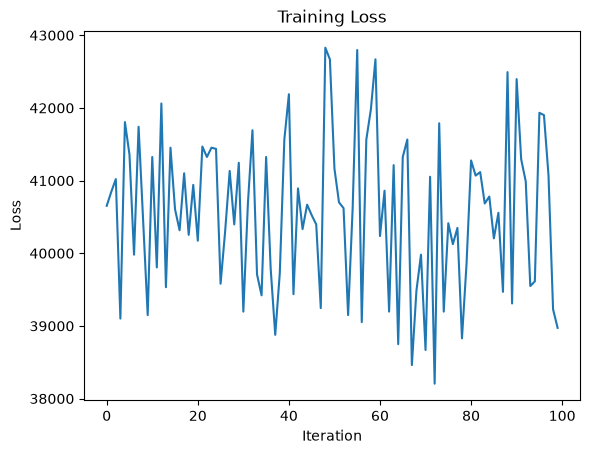

In [13]:
import matplotlib.pyplot as plt


class GradientDescentOptimizer:
    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate

    def update_weights(self, weights, gradients):
        return weights - self.learning_rate * gradients

    def update_bias(self, bias, gradient):
        return bias - self.learning_rate * gradient


class OneLayerPerceptronNeuralNetwork:
    def __init__(self, learning_rate=0.01, n_iter=100, n_perceptrons=10):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.n_perceptrons = n_perceptrons
        self.weights = None
        self.bias = None
        self.optimizer = GradientDescentOptimizer(learning_rate=self.learning_rate)
        self.loss_values = []

    def ReLU(self, values):
        return np.maximum(values, 0)

    def sigmoid(self, values):
        return 1 /(1 + np.exp(-values))

    def tanh(self, values):
        return np.tanh(values)

    def _activation_derivative(self, values):
        return (values > 0).astype(float)

    def compute_output(self, X):
        linear_output = self.weights.T @ X + self.bias
        return self.ReLU(linear_output)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        if y.ndim == 1:
            y = y.reshape(-1, 1)

        n_samples, n_features = X.shape

        self.weights = np.zeros(shape=(n_features, self.n_perceptrons))
        self.bias = np.ones(self.n_perceptrons) # a column of ones that will represent the bias to your train and test data
        self.loss_values = []

        for _ in range(self.n_iter):
            cumulative_loss = 0
            for x_i, y_i in zip(X, y):
                linear_output = self.compute_output(x_i)
                #y = self.ReLU(linear_output)
                y_predicted = np.argmax(linear_output)
                error = y_predicted - y_i

                cumulative_loss += self._loss_function(y_predicted, y_i)
                gradient = 2 * error * self._activation_derivative(linear_output)
                weight_gradients = gradient[:, np.newaxis] * x_i[np.newaxis, :]

                # or
                #
                #weight_gradients = np.outer(gradient, x_i)
                #

                self.weights = self.optimizer.update_weights(
                    self.weights, weight_gradients.T
                )
                self.bias = self.optimizer.update_bias(self.bias, gradient)

            self.loss_values.append(cumulative_loss)

        return self

    def _loss_function(self, y_predicted, y_true):
        return np.mean((y_predicted - y_true) ** 2)
    
    


def training_process_and_plot(X, y, learning_rate=0.01, n_iter=100):
    model = OneLayerPerceptronNeuralNetwork(
        learning_rate=learning_rate,
        n_iter=n_iter,
        n_perceptrons=10,
    )
    model.fit(X, y)
    plt.plot(model.loss_values)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()


training_process_and_plot(X, y, learning_rate=0.01, n_iter=100)

As we can see, something doesn't seem to be right.
Which in fact, it isn't, since we don't need a gradient descent for some perceptrons which do not include activation functions, which make our model nonlinear.

Not only that, but our current architecture takes too much training time, which led us to redefine some steps in a more efficient and optimized way.

In [49]:
X_test = test_in.values
y_test = test_out.values
y_test = np.asarray(y_test).ravel()

predictions = model.predict(X_test)
n_test_samples = np.arange(1, len(X_test) + 1)
acc_values = np.cumsum(predictions == y_test) / n_test_samples
print("predicts: ", len(predictions))
print("samples: ", len(n_test_samples))

predicts:  1000
samples:  1000


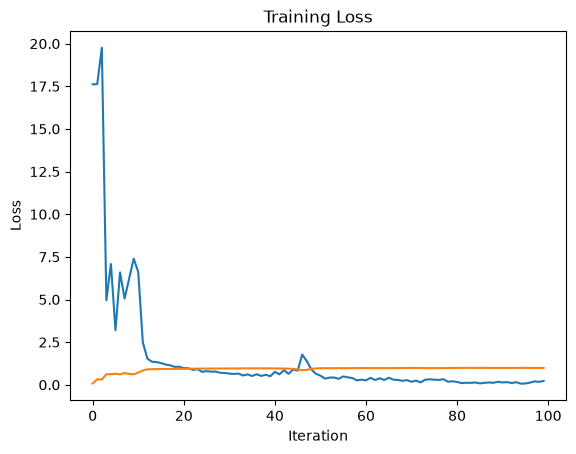

In [ ]:
import matplotlib.pyplot as plt


class GradientDescentOptimizer:
    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate

    def update_weights(self, weights, gradients):
        return weights - self.learning_rate * gradients

    def update_bias(self, bias, gradient):
        return bias - self.learning_rate * gradient


class OneLayerPerceptronNeuralNetwork:
    def __init__(self, learning_rate=0.01, n_iter=100, n_perceptrons=10, weights=np.random.rand(257,10)):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.n_perceptrons = n_perceptrons
        self.weights = weights
        self.bias = None
        self.optimizer = GradientDescentOptimizer(learning_rate=self.learning_rate)
        self.loss_values = []
        self.accuracy_values = []

    def ReLU(self, values):
        return np.maximum(values, 0)

    def sigmoid(self, values):
        return 1 /(1 + np.exp(-values))

    def tanh(self, values):
        return np.tanh(values)

    def _activation_derivative(self, values):
        return (values > 0).astype(float)

    def compute_output(self, X):
        return X @ self.weights

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        n_samples, n_features = X.shape
        #self.bias = np.ones(n_samples, 1) # a column of ones that will represent the bias to your train and test data

        # matrix T which will represent all our data, augmented with the bias vector of ones
        T = np.hstack([X, np.ones((n_samples, 1))])

        for _ in range(self.n_iter):
            linear_output = self.compute_output(T)
                #y = self.ReLU(linear_output)
            y_predicted = np.argmax(linear_output, axis=1)
            loss = np.mean((y_predicted - y) ** 2)

            # bad predictions
            bad_pred = y_predicted != y

            # accuracy metric prediction
            acc = np.mean(~bad_pred)

            # append values
            self.accuracy_values.append(acc)
            self.loss_values.append(loss)

            if not bad_pred.any():
                break
                
            # in order to improve our parameters, the idea behind this loop is to reinforce
            # the weights related with the output correctly predicted
            # and to punish those which failed
            for i in range(len(y)):
                if y_predicted[i] != y[i]:
                    x_i = T[i]
                    true_class = y[i]
                    pred_class = y_predicted[i]
                    self.weights[:, true_class] += self.learning_rate * x_i
                    self.weights[:, pred_class] -= self.learning_rate * x_i

                # or
                #
                #weight_gradients = np.outer(gradient, x_i)
                #

        return self

    def _loss_function(self, y_predicted, y_true):
        return np.mean((y_predicted - y_true) ** 2)

    def predict(self, X):
        X = np.asarray(X)
        T = np.hstack([X, np.ones(shape=(X.shape[0], 1))])
        linear_output = self.compute_output(T)
        value = np.argmax(linear_output, axis=1)
        return value

    def evaluate_and_plot(self, X, y):
        y = np.asarray(y).ravel()
        predictions = self.predict(X)
        n_test_samples = np.arange(1, len(X) + 1)
        loss_values = (predictions - y)**2
        acc_values = np.cumsum(predictions == y) / n_test_samples

        # plot the values
        fig, (loss_ax, acc_ax) = plt.subplots(2, 1, figsize=(10, 7))
        loss_ax.scatter(n_test_samples, loss_values)
        loss_ax.set_ylabel("Loss values for test data")
        loss_ax.set_title("Test performance by sample")

        acc_ax.plot(n_test_samples, acc_values)
        acc_ax.set_ylabel("(Cumulative) Accuracy values for test data")
        acc_ax.set_xlabel("Test sample")
        acc_ax.set_ylim(0, 1)

        plt.tight_layout()
        plt.show()

        return loss_values.mean(), np.mean(predictions == y)

def training_process_and_plot(X, y, learning_rate=0.01, n_iter=100, n_perceptrons=10, weights=None):
    model = OneLayerPerceptronNeuralNetwork(
        learning_rate=learning_rate,
        n_iter=n_iter,
        n_perceptrons=n_perceptrons,
        weights=weights
    )
    model.fit(X, y)
    plt.plot(model.loss_values, label="Training loss")
    plt.plot(model.accuracy_values, label="Cool training accuracy")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    return model


n_samples, n_features = X.shape
n_perceptrons = 10

model = training_process_and_plot(X, y, learning_rate=0.08, n_iter=100,n_perceptrons=10, weights=np.random.rand(n_features+1, n_perceptrons)) # "+1" since we are dealing with an additional column (a.k.a the bias column added to the T matrix)
model

### trying on test data:

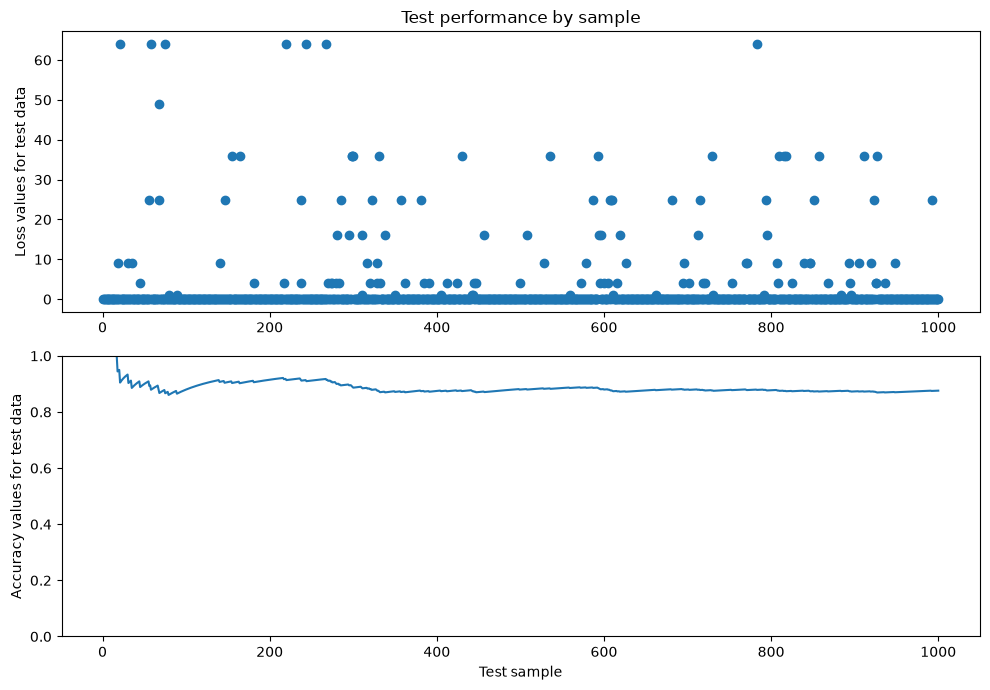

Test loss: 2.041
Test accuracy: 0.876


In [74]:
X_test = test_in.values
y_test = test_out.values

test_loss, test_accuracy = model.evaluate_and_plot(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

## Initializing weights as 0s + 0.08 of learning rate

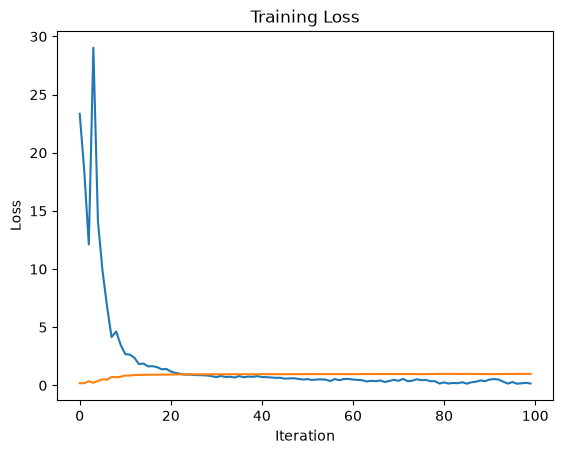

In [69]:
model = training_process_and_plot(X, y, learning_rate=0.08, n_iter=100,n_perceptrons=10, weights=np.zeros(shape=(n_features+1, n_perceptrons))) # "+1" since we are dealing with an additional column (a.k.a the bias column added to the T matrix)
model

### test data:

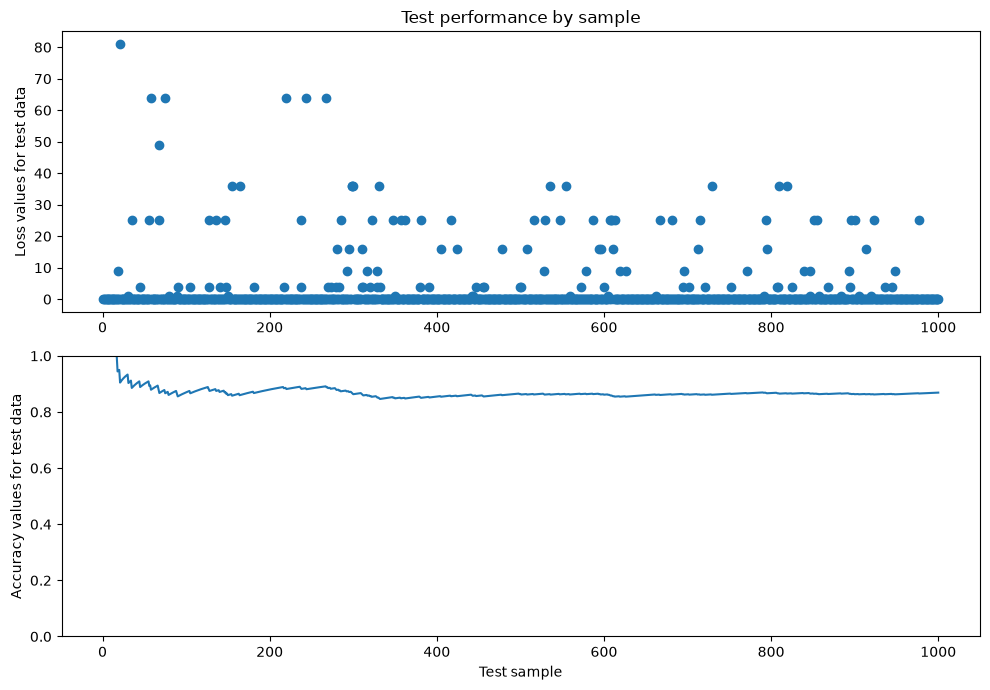

Test loss: 2.148
Test accuracy: 0.869


In [70]:
X_test = test_in.values
y_test = test_out.values

test_loss, test_accuracy = model.evaluate_and_plot(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

## Weights initialized in an uniformly randomized way + 0.78 of learning rate

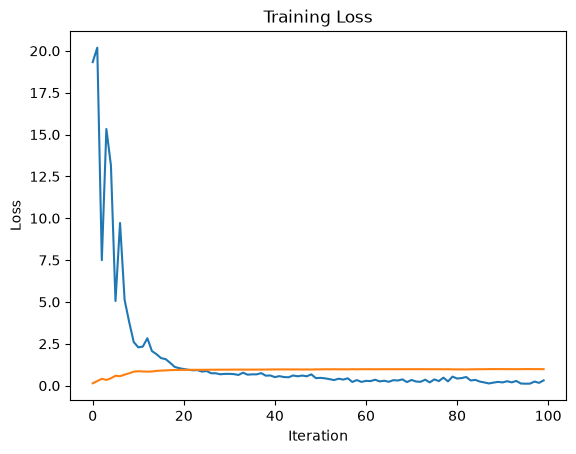

In [71]:
model = training_process_and_plot(X, y, learning_rate=0.78, n_iter=100,n_perceptrons=10, weights=np.random.uniform(low=0.02,high=4.53,size=(n_features+1, n_perceptrons))) # "+1" since we are dealing with an additional column (a.k.a the bias column added to the T matrix)
model

### test data:

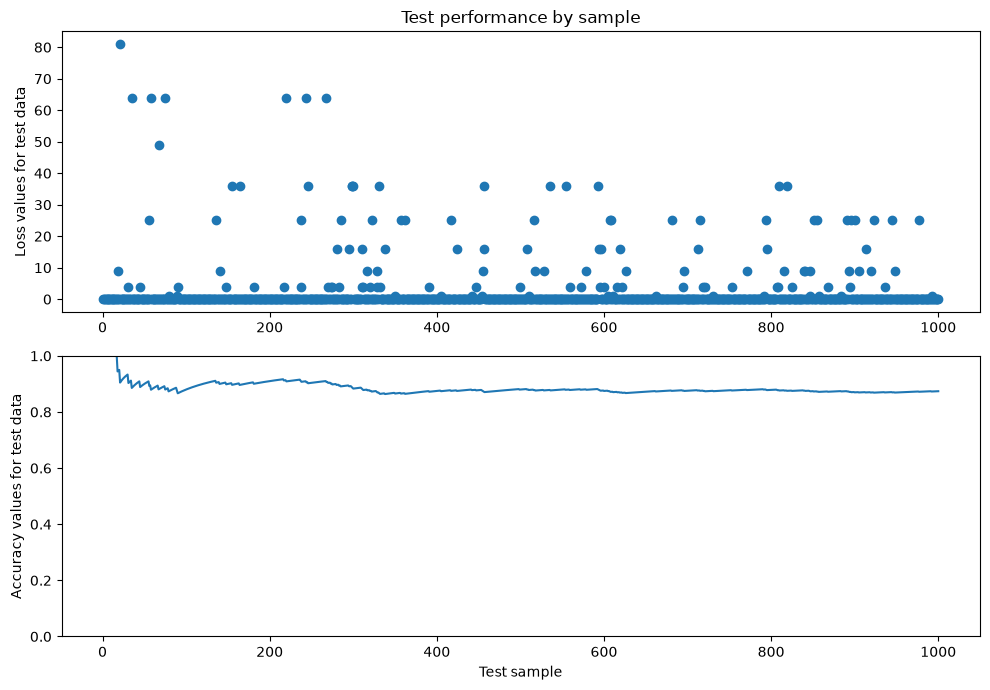

Test loss: 2.067
Test accuracy: 0.874


In [72]:
X_test = test_in.values
y_test = test_out.values

test_loss, test_accuracy = model.evaluate_and_plot(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)